In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=30
)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

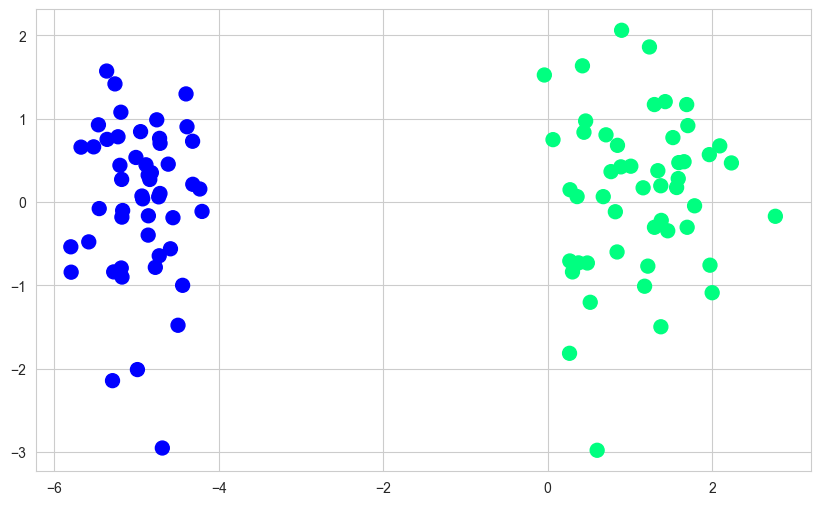

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

# Using Sklearn

[Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

## 🔹 `penalty`

**Type:** `{'l1', 'l2', 'elasticnet', None}`
**Default:** `'l2'`

Specifies the norm of the penalty:

* `None` → No penalty is added
* `'l2'` → Adds L2 penalty term (**default**)
* `'l1'` → Adds L1 penalty term
* `'elasticnet'` → Adds both L1 and L2 penalties

---

## 🔹 `C`

**Type:** `float`
**Default:** `1.0`

Inverse of regularization strength:

* Smaller values → **stronger regularization**
* Larger values → **weaker regularization**
* `C = np.inf` → No regularization

---

## 🔹 `l1_ratio`

**Type:** `float`
**Default:** `0.0`

Elastic-Net mixing parameter (`0 ≤ l1_ratio ≤ 1`):

* `l1_ratio = 1` → Pure L1 penalty
* `l1_ratio = 0` → Pure L2 penalty
* Between `0` and `1` → Combination:

  ```
  l1_ratio * L1 + (1 - l1_ratio) * L2
  ```

---

## 🔹 `dual`

**Type:** `bool`
**Default:** `False`

* Chooses between **dual** or **primal** formulation
* Only supported for **L2 penalty with `liblinear` solver**
* Prefer `dual=False` when `n_samples > n_features`

---

## 🔹 `tol`

**Type:** `float`
**Default:** `1e-4`

Tolerance for stopping criteria.

---

## 🔹 `fit_intercept`

**Type:** `bool`
**Default:** `True`

* Whether to add a **bias (intercept)** term

---

## 🔹 `intercept_scaling`

**Type:** `float`
**Default:** `1`

Used only when:

* Solver = `liblinear`
* `fit_intercept = True`

Adds a synthetic feature:

```
x → [x, intercept_scaling]
```

Intercept becomes:

```
intercept_scaling × synthetic_feature_weight
```

---

## 🔹 `class_weight`

**Type:** `dict` or `'balanced'`
**Default:** `None`

* Custom weights:

  ```
  {class_label: weight}
  ```
* `'balanced'` mode:
  Automatically adjusts weights:

  ```
  n_samples / (n_classes * np.bincount(y))
  ```

> Note: Multiplied with `sample_weight` if provided.

---

## 🔹 `random_state`

**Type:** `int` or `RandomState`
**Default:** `None`

Used for reproducibility when using:

* `'sag'`
* `'saga'`
* `'liblinear'`

---

## 🔹 `solver`

**Type:** `{'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}`
**Default:** `'lbfgs'`

### Solver Guidelines:

* `'lbfgs'` → Good default for most problems
* `'liblinear'` → Good for small datasets (binary classification only)
* `'sag'`, `'saga'` → Faster for large datasets
* `'newton-cholesky'` → Good when:

  ```
  n_samples >> n_features * n_classes
  ```

  ⚠️ High memory usage (quadratic in features)

### Multiclass Notes:

* All solvers except `'liblinear'` support **multinomial loss**
* `'liblinear'` requires:

  ```
  OneVsRestClassifier
  ```

---

## 🔹 `max_iter`

**Type:** `int`
**Default:** `100`

Maximum number of iterations for convergence.

---

## 🔹 `verbose`

**Type:** `int`
**Default:** `0`

* Set > 0 for detailed logs
* Works with:

  * `'liblinear'`
  * `'lbfgs'`

---

## 🔹 `warm_start`

**Type:** `bool`
**Default:** `False`

* `True` → Reuse previous solution
* `False` → Start fresh

⚠️ Not useful for `liblinear`

---

## 🔹 `n_jobs`

**Type:** `int`
**Default:** `None`

* **No effect** in this context

---




In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    solver='sag'
)
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [6]:
m = -(lr.coef_[0][0] / lr.coef_[0][1])
b = -(lr.intercept_[0] / lr.coef_[0][1])


In [7]:
x_input = np.linspace(-3, 3, 100)
y_input_lr = m * x_input + b

(-3.0, 2.0)

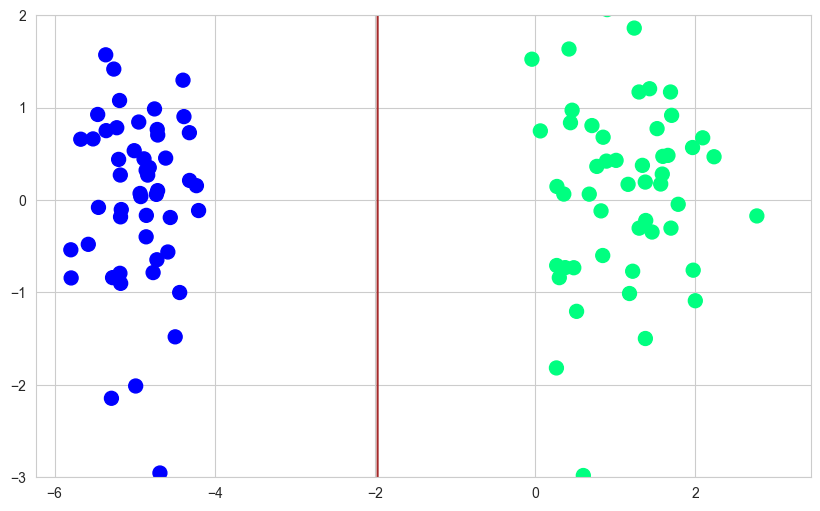

In [8]:
m = -(lr.coef_[0][0] / lr.coef_[0][1])
b = -(lr.intercept_[0] / lr.coef_[0][1])

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

plt.plot(x_input, y_input_lr, color='brown')
plt.ylim(-3, 2)